In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import matplotlib as mpl
from scipy.optimize import curve_fit

# seaborn-v0_8 is the modern name for the classic seaborn style
plt.style.use('seaborn-v0_8-whitegrid')


def normal_incident(erwartungswert, lim):
    damage = np.random.exponential(scale = erwartungswert)
    if damage > lim: return lim
    else: return damage

def pareto_incident(minimum, alpha, lim):
    damage =  minimum * (np.random.pareto(alpha) + 1)
    if damage > lim: return lim
    else: return damage


def Insurance(starting_capital, insurance_rate, incident_rate, mu, lim, N_years, pareto_incitent = False, alpha = None):

    time = 0.0
    zero_time = 0.0

    timestamps = np.array([time])
    budgetstamps = np.array([starting_capital])
    budget = starting_capital


    while time <= N_years:

        waiting_time = np.random.exponential(scale = incident_rate)
        time += waiting_time

        budget += insurance_rate * waiting_time

        if pareto_incitent:
            damage = pareto_incident(mu, alpha, lim)
            budget -= damage
            budgetstamps = np.append(budgetstamps, budget)
            timestamps = np.append(timestamps, time)
        
        else:
            damage = normal_incident(mu, lim)
            budget -= damage
            budgetstamps = np.append(budgetstamps, budget)
            timestamps = np.append(timestamps, time)
        
        if budget <= 0 and zero_time == 0.0 : zero_time = time
        
        
        # if budget <= 0:
        #     np.append(timestamps, 0)
    return budgetstamps, timestamps, zero_time


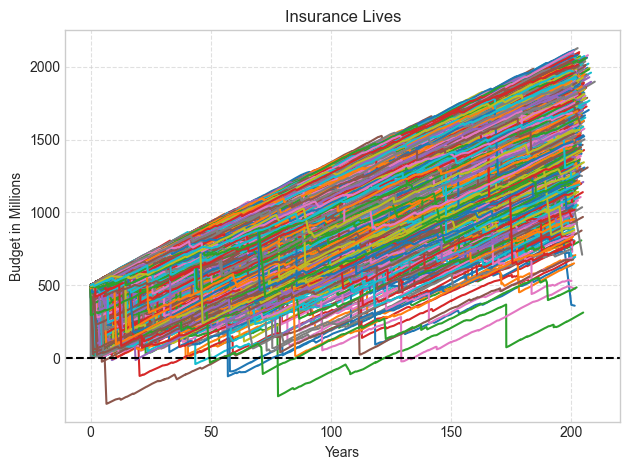

In [50]:

u   = 500.0   # Startkapital
c   = 10   # Prämienrate 
lam = 1.0    # Schadensrate 
mu  = 1.0    # Erwartete Schadenshöhe (Exponentialverteilung), Mindestbetrag zur Übernahme (pareto)
lim = 500    # Deckungslimit
T   = 200.0  # Zeithorizont
N   = 10000 # Anzahl simulierter "Leben"




def simulator(u, c, lam, mu, lim, T, N, pareto = False, alpha = None):
    
    ts_ruin = np.zeros(N)
    final_budget = np.zeros(N)
    
    for j in range(N):

        budget, time, ruin_time = Insurance(u,c,lam,mu,lim,T, pareto, alpha)
        plt.plot(time,budget)

        ts_ruin[j] = ruin_time
        
        if ruin_time == 0.0:
            final_budget[j] = budget[-1]
        else:
            final_budget[j] = 0.0
    

    plt.title("Insurance Lives")
    plt.xlabel("Years")
    plt.ylabel("Budget in Millions")
    plt.grid(True)
    plt.axhline(y=0, color='Black', linestyle='--', label='Ruin Line')
    plt.grid(True, which='major', linestyle='--', alpha=0.6)
    plt.minorticks_on()
    plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    plt.tight_layout()            
    plt.show()


    return ts_ruin, final_budget


ts_ruin, final_budget = simulator(u,c,lam,mu,lim, T,N, True, 1.3)



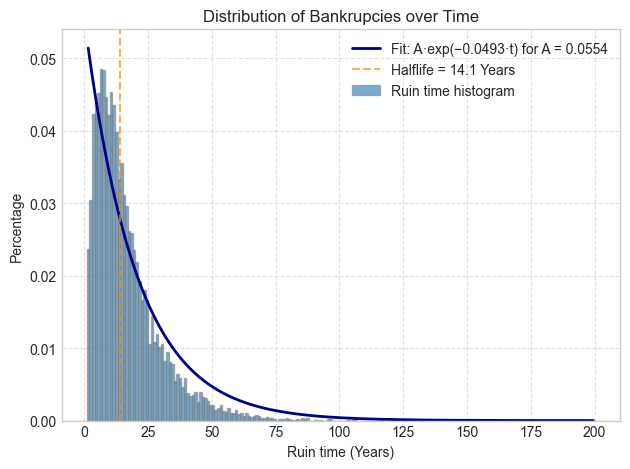

A = 0.055,  λ = 0.04929,  half-life = 14.1


In [ ]:
hist, bin_edges = np.histogram(ts_ruin, 200, (0,200), density = True)

def fit_ruin_histogram(hist, bin_edges):
    counts = hist[1:].astype(float)
    midpoints = 0.5 * (bin_edges[1:-1] + bin_edges[2:])

    def exponential(t, A, lam):
        return A * np.exp(-lam * t)

    popt, pcov = curve_fit(exponential, midpoints, counts, p0=[counts[0], 0.01])
    A, lam = popt
    halflife = np.log(2)/lam


    t_fit = np.linspace(midpoints[0], midpoints[-1], 300)
    y_fit = exponential(t_fit, A, lam)


    fig, ax = plt.subplots()
    ax.bar(midpoints, counts, width=midpoints[1] - midpoints[0], alpha=0.6, label="Ruin time histogram", edgecolor = "grey")
    ax.plot(t_fit, y_fit, "darkblue", lw=2, label=f"Fit: A·exp(−{lam:.4f}·t) for A = {np.round(A, 4)}")
    ax.set_xlabel("Ruin time (Years)")
    ax.set_ylabel("Percentage")
    ax.set_title("Distribution of Bankrupcies over Time")
    ax.axvline(x=halflife, color='darkorange', linestyle='--', alpha = 0.7, label=f'Halflife = {halflife:.1f} Years')
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)            
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"A = {A:.3f},  λ = {lam:.5f},  half-life = {np.log(2)/lam:.1f}")
    return counts, midpoints

counts, midpoints = fit_ruin_histogram(hist, bin_edges)







Total Ruins: 0, Total successes: 10000, Ration (Ruins/Total) : 0.0
Average ending Budget: nan Millions
Difference Starting - Ending Budget: nan Millions


/Users/juliusfelner/Desktop/Coding/Python/showcase_project/showcase_env/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/Users/juliusfelner/Desktop/Coding/Python/showcase_project/showcase_env/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


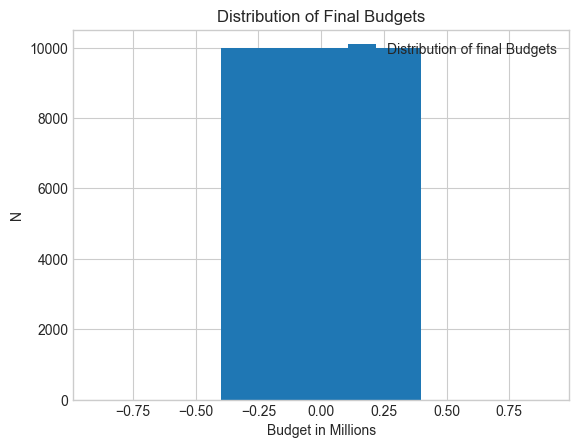

In [ ]:
b_hist, b_bin_edges = np.histogram(final_budget, 1000)


ruins = b_hist[0]
no_ruins = np.sum(b_hist[1:])
average_ending_budget = np.round(np.average([i for i in final_budget - u if i != -10]), 1)



print(f"Total Ruins: {ruins}, Total successes: {no_ruins}, Ration (Ruins/Total) : {ruins/(ruins + no_ruins)}")
print(f"Average ending Budget: {average_ending_budget} Millions")
print(f"Difference Starting - Ending Budget: {average_ending_budget - u} Millions")


plt.bar(b_bin_edges[1:-1], b_hist[1:], label = "Distribution of final Budgets")
plt.title("Distribution of Final Budgets")
plt.xlabel("Budget in Millions")
plt.ylabel("N")
plt.legend()